# Week 2 · Day 5 — Unsupervised Learning & Module 1 Wrap-Up

**Course:** IPAM USL 5-Week Short Course: Introduction to Artificial Intelligence *(Introductory tier)*

**Facilitator:** Solomon Wilson MBCS | PhD Student, Computer Science | Deputy HOD Transport Planning & Operations | HOD, IT & Audit Supervisor, SLPTA

**Mode:** Google Colab (zero-install)

**Mental model layer:** L5 — Unsupervised Learning

**Running scenario:** Route **R12** (Wilberforce → CBD) — operator OP-104, 25-minute delay

**Module:** 1 · **Week:** 2 · **Tier:** Intro  
**New concept:** (Integration day — no new concept. Today we consolidate Module 1.)  
**Deliverable wired in:** D1 — Problem Statement (15%)

## Learning objectives
By the end of today you will be able to:
- Explain how **clustering** finds groups in data with **no labels**.
- Use **k-means** to segment SLPTA operators by performance, and **PCA** to see the groups in 2-D.
- Choose a dataset and write a one-page problem statement (**Deliverable 1**).

## Why this matters for SLPTA

So far we *told* the model the answer (delayed or not, how many minutes). But sometimes nobody has labelled anything — we just have 20 operators and want to ask: *which operators behave alike?* Clustering groups them automatically, so management can see at a glance who is reliable and who needs support. No one writes the groups down; the data reveals them.

## Environment setup

In [1]:
# Today's lab uses pandas + scikit-learn (both preinstalled in Colab). We also
# install google-genai so the SAME bootstrap import line works in every notebook.
!pip install -q google-genai
print("Environment ready.")

Environment ready.


In [2]:
# --- Standard SLPTA bootstrap (identical in every notebook) ----------------
import sys
from pathlib import Path
for candidate in [Path.cwd(), *Path.cwd().parents,
                  Path("/content/IPAM_USL_Intro_AI_5Week")]:
    if (candidate / "shared" / "slpta_bootstrap.py").exists():
        sys.path.insert(0, str(candidate / "shared"))
        break

from slpta_bootstrap import (MODEL, ensure_course_data, get_client,
                             load_route12_context, load_route_logs,
                             load_complaints, load_routes, load_operators)

ensure_course_data()
print("Model configured:", MODEL)
print(load_route12_context())

Model configured: gemini-2.0-flash
Route R12 (Wilberforce → CBD). The 07:45 service, operated by OP-104 on vehicle SLPTA-1142, departed 25 minutes late. Recorded cause: Heavy traffic on Wilkinson Road. About 40 passengers were affected and the dispatch desk received multiple complaints. (Synthetic SLPTA scenario — no real data.)


## Concept — first principles

**Unsupervised learning** finds structure in data that has **no answer column**.
- **k-means clustering** puts each row into one of *k* groups so members of a group are as similar as possible. *You* choose *k*.
- **PCA (Principal Component Analysis)** squashes many columns down to two so we can plot them — like drawing a 3-D object on flat paper. It is for *seeing*, not predicting.

*Jargon, defined once:* a **cluster** is a group the algorithm discovered; we interpret what it means afterwards.

<p align="center"></p>

<!-- cell-diagram:c09 -->
<p align="center"></p>

### Check your understanding (before running)
This cell loads all route logs and builds a **performance profile** for each of the 20 SLPTA operators.

Before running:
- Which metric do you expect to vary most across operators — average delay, percentage badly delayed, or average passengers?
- OP-104 operates Route R12 and had a 25-minute delay in our scenario. Do you expect it to appear in the high-delay or low-delay group?

*Write your prediction, then run.*

In [5]:
import pandas as pd

# --- 1. DATA LOADING ---
# Retrieve raw trip logs from the SLPTA database via bootstrap utility
logs = load_route_logs()

# --- 2. DATA CLEANING & INTEGRITY ---
# Remove duplicate rows to prevent double-counting trips
logs = logs.drop_duplicates()

# Define the upper threshold for 'normal' delays (3 hours)
MAX_DELAY_THRESHOLD = 180

# Filter out extreme outliers to ensure clustering represents typical performance
mask_valid_delays = logs["delay_minutes"] < MAX_DELAY_THRESHOLD
logs = logs[mask_valid_delays].copy()

# --- 3. MISSING VALUE HANDLING (IMPUTATION) ---
# Calculate the median passenger count for the dataset
median_passengers = logs["passenger_count"].median()

# Impute missing passenger values with the median to maintain record count
logs["passenger_count"] = logs["passenger_count"].fillna(median_passengers)

# --- 4. OPERATOR PERFORMANCE PROFILING ---
# Group the data by operator unique identifier
log_groups = logs.groupby("operator_id")

# Define specific aggregation metrics for the performance report
# avg_delay: Mean minutes of delay per trip
# pct_badly_delayed: Frequency of delays exceeding 15 minutes
# avg_passengers: Average load per trip
# n_trips: Total volume of service provided
aggregation_metrics = {
    "avg_delay": ("delay_minutes", "mean"),
    "pct_badly_delayed": ("delay_minutes", lambda s: (s > 15).mean()),
    "avg_passengers": ("passenger_count", "mean"),
    "n_trips": ("trip_id", "count")
}

# Generate the summary profile per operator
profile = log_groups.agg(**aggregation_metrics)

# Flatten the multi-index to convert operator_id back into a column
profile = profile.reset_index()

# --- 5. DATA PREVIEW ---
# Output the first 5 records of the processed operator dataset
final_preview = profile.head()
display(final_preview)

,operator_id,avg_delay,pct_badly_delayed,avg_passengers,n_trips
0,OP-101,13.992708,0.427083,19.135417,96
1,OP-102,6.470115,0.126437,20.241379,87
2,OP-103,9.800000,0.208791,21.549451,91
3,OP-104,13.535780,0.394495,20.908257,109
4,OP-105,8.432143,0.178571,20.547619,84


<!-- cell-diagram:c11 -->
<p align="center"></p>

### Check your understanding (before running)
**Predict:** we will ask k-means for **3** operator groups. Before running — what do you think the three groups will turn out to mean in dispatch terms?

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# --- 1. FEATURE SELECTION ---
# Select the specific columns to be used for profiling operator behavior
features = ["avg_delay", "pct_badly_delayed", "avg_passengers", "n_trips"]
feature_data = profile[features]

# --- 2. DATA NORMALIZATION (SCALING) ---
# Initialize the standard scaler to normalize feature ranges
scaler = StandardScaler()

# Fit and transform the data so that all features share a common scale (mean=0, std=1)
# This is critical because K-Means is a distance-based algorithm
Z = scaler.fit_transform(feature_data)

# --- 3. CLUSTER MODELING ---
# Define the number of groups (clusters) to discover
NUM_CLUSTERS = 3

# Initialize the K-Means algorithm with a fixed random seed for reproducibility
km = KMeans(n_clusters=NUM_CLUSTERS, n_init=10, random_state=0)

# Execute the clustering algorithm and assign each operator to a cluster index
cluster_labels = km.fit_predict(Z)

# Add the discovered cluster labels to our main profile DataFrame
profile["cluster"] = cluster_labels

# --- 4. CLUSTER INTERPRETATION ---
# Group the results by the new 'cluster' ID to see the profile of each group
cluster_summary = profile.groupby("cluster")

# Calculate the average performance metrics per cluster to understand what they represent
cluster_averages = cluster_summary[features].mean()

# Round the values for cleaner display in the dashboard
final_summary = cluster_averages.round(2)

# Display the final summary table
display(final_summary)

,avg_delay,pct_badly_delayed,avg_passengers,n_trips
cluster,,,,
0,8.18,0.18,21.35,92.00
1,11.88,0.32,19.42,90.82
2,17.03,0.55,19.95,105.00


---
## Extension: Visualising Clusters with PCA (optional — for early finishers)

> **This section is optional.** Complete the k-means clustering exercise below first.
> PCA (Principal Component Analysis) squashes many columns down to 2 so we can **see** the groups on a chart — it is for visualisation, not prediction. We explore PCA more fully in Module 2.  
> If you have time: run the cell below and observe how the three operator clusters separate in 2-D.

<!-- cell-diagram:c13 -->
<p align="center"></p>

### Check your understanding (before running)
This cell runs: `import matplotlib.pyplot as plt`

**Predict:** Before you run it, what output do you expect for Route **R12** (Wilberforce → CBD, OP-104, 25-minute delay)? Write your guess.

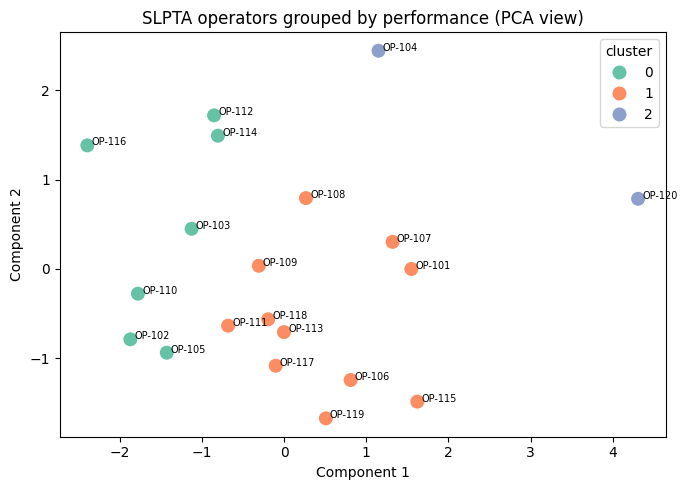

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# --- 1. DIMENSIONALITY REDUCTION (PCA) ---
# Initialize PCA to reduce our 4-dimensional profile data into 2 dimensions
# This allows us to visualize high-dimensional clusters on a 2D plane
pca_model = PCA(n_components=2, random_state=0)

# Fit and transform the scaled data (Z) into principal components
coords = pca_model.fit_transform(Z)

# --- 2. DATA PREPARATION FOR PLOTTING ---
# Create a copy of the profile data to avoid modifying the original dataframe
plot_df = profile.copy()

# Extract the first principal component (x-axis)
plot_df["x"] = coords[:, 0]

# Extract the second principal component (y-axis)
plot_df["y"] = coords[:, 1]

# --- 3. VISUALIZATION ---
# Set up the figure dimensions
plt.figure(figsize=(7, 5))

# Create a scatter plot where points are colored by their cluster assignment
sns.scatterplot(
    data=plot_df,
    x="x",
    y="y",
    hue="cluster",
    palette="Set2",
    s=120
)

# Iterate through the rows to add text labels for each operator_id
for index, row in plot_df.iterrows():
    # Offset text slightly to the right of the point for readability
    plt.text(row["x"] + 0.05, row["y"], row["operator_id"], fontsize=7)

# Add descriptive chart metadata
plt.title("SLPTA operators grouped by performance (PCA view)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

# Optimize the layout to prevent clipping and display the plot
plt.tight_layout()
plt.show()

Read the cluster table together with the plot: one group has low average delay (reliable operators), one is middling, and a small group has high delay and a high share of badly delayed trips (operators who need support). The algorithm found that split on its own — no labels required.

---
*End of extension section. Continue with the k exercise below.*

### Exercise — change the number of clusters

Change `k` below to `2`, then `4`, and re-run. Fewer clusters = coarser groups; more = finer. There is no single "right" *k* — it depends on the decision you are supporting.

<!-- cell-diagram:c18 -->
<p align="center"></p>

### Check your understanding (before running)
This exercise re-runs k-means with a **different value of k**.

Before running:
- If you change k from 3 to 2, what do you expect to happen to the cluster sizes — will the two groups be roughly equal, or unequal?
- If you change k to 4, will the algorithm find a genuinely meaningful 4th group, or might it just split one existing group in two?

*Write your prediction, change the value of `k`, then run.*

In [8]:
# --- EXERCISE: SENSITIVITY ANALYSIS ---
# TODO: Change k to 2, then 4, and re-run. Observe how the grouping granularity changes.
# A smaller k results in broader generalizations; a larger k creates niche segments.

# Define the target number of clusters for this experiment
k = 3

# Initialize the K-Means estimator with the selected k value
# We use n_init=10 to ensure the algorithm finds a stable local optimum
model_k = KMeans(n_clusters=k, n_init=10, random_state=0)

# Fit the model to the scaled data and generate cluster labels
labels = model_k.fit_predict(Z)

# Store the experimental labels in a new column to preserve our primary analysis
profile["cluster_k"] = labels

# --- REPORTING ---
# Count the number of operators assigned to each specific group
counts_per_cluster = profile["cluster_k"].value_counts()

# Sort the indices (0, 1, 2...) for consistent display
sorted_counts = counts_per_cluster.sort_index()

# Print the results to the console
print(f"k = {k}  ->  operators per cluster:")
print(sorted_counts.to_string())

k = 3  ->  operators per cluster:
cluster_k
0     7
1    11
2     2


---
## Module 1 wrap — what we have built

In five days we went from "what is AI?" to a working analytics toolkit on SLPTA data:

| Day | Idea | We can now… |
|----:|------|-------------|
| 1 | Rules vs. learning | Tell apart a hand-written rule and a learned one |
| 2 | Data as fuel | Clean, encode, and split a messy route log |
| 3 | Classification | Flag trips likely to be badly delayed |
| 4 | Regression | Predict how many minutes late a trip will run |
| 5 | Unsupervised | Group operators by performance with no labels |

## Deliverable 1 — Problem Statement (graded, 15%)

Choose **one** SLPTA problem you will carry through to your capstone. Use the synthetic `course_data/` (route logs, complaints, operators, policies). Fill in the cell below — about one page. *Due end of Day 5.*

### My problem statement
*Double-click to edit. Keep it to roughly one page.*

**1. The problem (2–3 sentences).**

**2. The dataset I will use** (which `course_data/` file(s), which columns):

**3. Is this classification, regression, or clustering? Why:**

**4. What "good" looks like** (how I will measure success — e.g. MAE under X, recall above Y):

**5. One risk or limitation** (what could go wrong, or when SLPTA should not rely on it):

## Check your understanding
1. How is unsupervised learning different from the classification and regression we did on Days 3–4?
2. Why must we **scale** the operator features before running k-means?
3. What is PCA used for here — predicting, or seeing? Explain.

### Your answers
*Double-click to edit this cell and type your answers here.*

1.
2.
3.

## If you remember one thing today…

> **Clustering finds groups in unlabelled data — you choose how many, then you give the groups their meaning.**

## Submission checklist
- [ ] Run every code cell successfully (top to bottom)
- [ ] Complete the exercise (fill every blank / make the requested change)
- [ ] Answer the **Check your understanding** questions in the markdown cell provided
- [ ] Save a clean copy of the notebook (*File → Save a copy in Drive*)